In [1]:
# Initialization of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import sklearn
import seaborn as sns
import statsmodels.api as sm
import glob
import os


from xgboost import XGBClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from ModelingFunctions.GEMpythonlib.GEMpythonfunctions import * 

In [2]:
# Array or dataframe initialization
data = []

# Constant initialization
minutes_interval = 2

# Constants
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

# unit changes
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592


# List of emissions
emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

In [32]:
# Data loading

# Opening files
file_list = ['Voltage Time Series-data-2025-04-07 23_59_02.csv',
             'Voltage Time Series-data-2025-04-07 23_59_17.csv',
             'Voltage Time Series-data-2025-04-07 23_59_29.csv',
             'Voltage Time Series-data-2025-04-07 23_59_45.csv']

file_path = '../../data/1. Combination 1_Walikale/'

# Initialize an empty list to collect DataFrames
data = []

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path + file)
    data.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data, ignore_index=True)
data['Time'] = pd.to_datetime(data['Time'], format="%Y-%m-%d %H:%M:%S")

# Display the final concatenated DataFrame
display(data)

is_valid, invalid_data = check_time_intervals(data)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)
    
df = data[['Time','Frequency 64B734C2 (Hgr Walikale - Cabane)']]
df

,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane)
0,2023-01-01 00:00:00,50.0,50.0,230.0,228.0
1,2023-01-01 00:02:00,50.0,50.0,230.0,228.0
2,2023-01-01 00:04:00,50.0,50.0,230.0,228.0
3,2023-01-01 00:06:00,50.0,50.0,230.0,229.0
4,2023-01-01 00:08:00,50.0,50.0,230.0,228.0
...,...,...,...,...,...
20155,2023-01-28 23:50:00,50.0,NaN,230.0,NaN
20156,2023-01-28 23:52:00,50.0,50.0,230.0,227.0
20157,2023-01-28 23:54:00,50.0,NaN,230.0,NaN
20158,2023-01-28 23:56:00,50.0,50.0,230.0,228.0


Some rows are not separated by exactly 2 minutes.
Invalid rows:


,Time,Frequency 09B35150 (Hgr Walikale - Lab),Frequency 64B734C2 (Hgr Walikale - Cabane),Voltage 09B35150 (Hgr Walikale - Lab),Voltage 64B734C2 (Hgr Walikale - Cabane),time_diff
0,2023-01-01,50.0,50.0,230.0,228.0,NaT


,Time,Frequency 64B734C2 (Hgr Walikale - Cabane)
0,2023-01-01 00:00:00,50.0
1,2023-01-01 00:02:00,50.0
2,2023-01-01 00:04:00,50.0
3,2023-01-01 00:06:00,50.0
4,2023-01-01 00:08:00,50.0
...,...,...
20155,2023-01-28 23:50:00,NaN
20156,2023-01-28 23:52:00,50.0
20157,2023-01-28 23:54:00,NaN
20158,2023-01-28 23:56:00,50.0


/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_89389/364642348.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Frequency 64B734C2 (Hgr Walikale - Cabane)'] = df['Frequency 64B734C2 (Hgr Walikale - Cabane)'].replace(0, np.nan).ffill()
/var/folders/fz/752v568s4vs79b77drn5n2zm0000gp/T/ipykernel_89389/364642348.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HMM_State'] = hmm.predict(X)


Mean voltage per state:
HMM_State
0     50.003966
3     51.023631
1    100.462121
2    192.000000
Name: Frequency 64B734C2 (Hgr Walikale - Cabane), dtype: float64


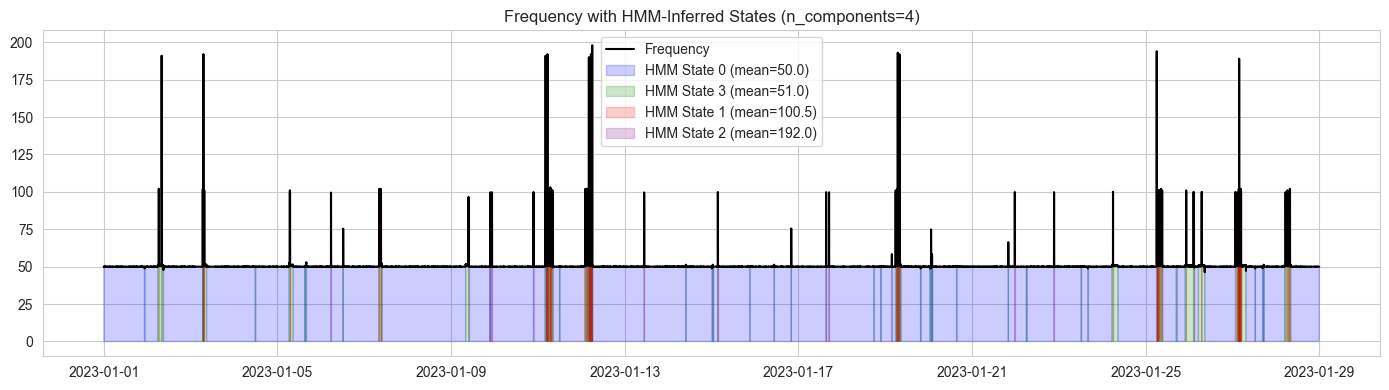

In [33]:
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import numpy as np

# Choose number of states to test (3 or 4)
n_states = 4  # or 3

# Use adjusted signal if available, e.g. 'New_Volt_Lab'
df['Frequency 64B734C2 (Hgr Walikale - Cabane)'] = df['Frequency 64B734C2 (Hgr Walikale - Cabane)'].replace(0, np.nan).ffill()
X = df['Frequency 64B734C2 (Hgr Walikale - Cabane)'].to_numpy().reshape(-1, 1)

# Fit HMM
hmm = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=1000, random_state=42)
hmm.fit(X)
df['HMM_State'] = hmm.predict(X)

# Show mean voltage per state for interpretation
state_means = df.groupby('HMM_State')['Frequency 64B734C2 (Hgr Walikale - Cabane)'].mean().sort_values()
print("Mean voltage per state:")
print(state_means)

# Plot each state in a different color
plt.figure(figsize=(14, 4))
plt.plot(df['Time'], df['Frequency 64B734C2 (Hgr Walikale - Cabane)'], label='Frequency', color='black')

colors = ['blue', 'green', 'red', 'purple']
for idx, state in enumerate(state_means.index):
    plt.fill_between(
        df['Time'],
        df['Frequency 64B734C2 (Hgr Walikale - Cabane)'],
        where=(df['HMM_State'] == state),
        color=colors[idx % len(colors)],
        alpha=0.2,
        label=f'HMM State {state} (mean={state_means[state]:.1f})'
    )

plt.title(f"Frequency with HMM-Inferred States (n_components={n_states})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

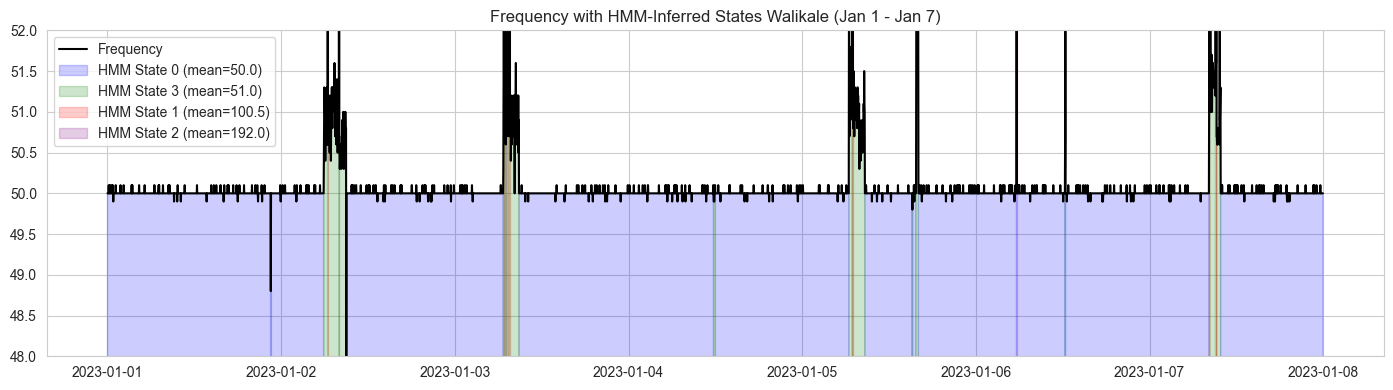

In [34]:
# Filter data for just one week (Jan 1 - Jan 7)
df_one_week = df[(df['Time'] >= "2023-01-01") & (df['Time'] < "2023-01-08")]

plt.figure(figsize=(14, 4))
plt.plot(df_one_week['Time'], df_one_week['Frequency 64B734C2 (Hgr Walikale - Cabane)'], 
         label='Frequency', color='black')

colors = ['blue', 'green', 'red', 'purple']
for idx, state in enumerate(state_means.index):
    plt.fill_between(
        df_one_week['Time'],
        df_one_week['Frequency 64B734C2 (Hgr Walikale - Cabane)'],
        where=(df_one_week['HMM_State'] == state),
        color=colors[idx % len(colors)],
        alpha=0.2,
        label=f'HMM State {state} (mean={state_means[state]:.1f})'
    )

plt.title(f"Frequency with HMM-Inferred States Walikale (Jan 1 - Jan 7)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(48, 52)
plt.show()

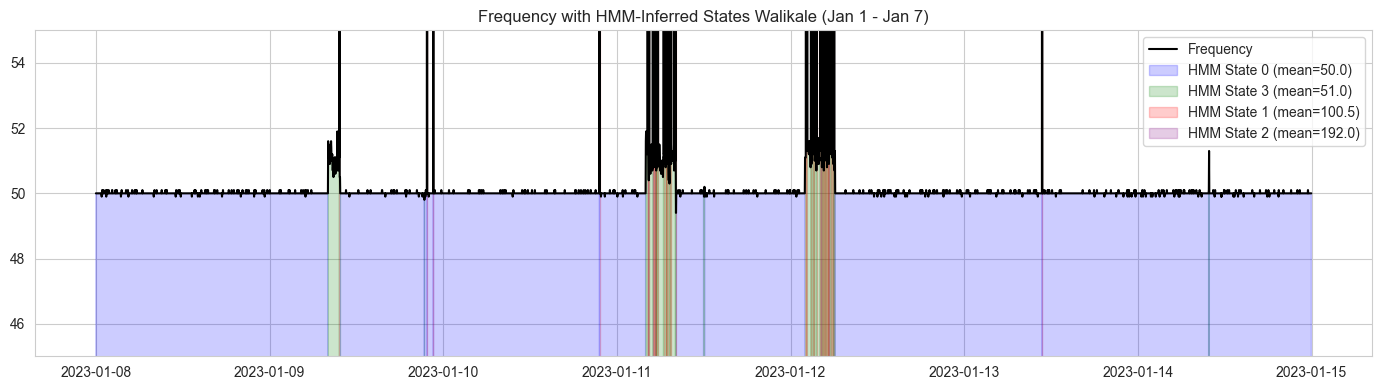

In [37]:
# Filter data for just one week (Jan 1 - Jan 7)
df_one_week = df[(df['Time'] >= "2023-01-08") & (df['Time'] < "2023-01-15")]

plt.figure(figsize=(14, 4))
plt.plot(df_one_week['Time'], df_one_week['Frequency 64B734C2 (Hgr Walikale - Cabane)'], 
         label='Frequency', color='black')

colors = ['blue', 'green', 'red', 'purple']
for idx, state in enumerate(state_means.index):
    plt.fill_between(
        df_one_week['Time'],
        df_one_week['Frequency 64B734C2 (Hgr Walikale - Cabane)'],
        where=(df_one_week['HMM_State'] == state),
        color=colors[idx % len(colors)],
        alpha=0.2,
        label=f'HMM State {state} (mean={state_means[state]:.1f})'
    )

plt.title(f"Frequency with HMM-Inferred States Walikale (Jan 1 - Jan 7)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(45, 55)
plt.show()